# Hierarchical Refinement with OTT‑JAX: Scalable Optimal Transport


### This notebook is a hands‑on tutorial showing how to implement Hierarchical Refinement using the low‑rank LRSinkhorn solver from ```OTT‑JAX```.

We experiment with the implementation of Hierachical Refinement based on the low-rank LRSinkhorn solver, proposed by [Halmos et al., 2025]([text](https://arxiv.org/pdf/2503.03025)). 
This algorithm to scalably compute a full-rank, bijective alignment between two equally-sized input datasets X and Y by solving a hierarchy of low-rank OT sub-problems. 

___

**1. Installation & Setup**
* Installing OTT‑JAX and dependencies  

**2. Generating Synthetic Data** 
* Creating two toy point clouds of equal cardinality,  each with a uniform mass
* Visualizing source and target  

**3. Low‑Rank partitions with LRSinkhorn**  
* Formulating the rank‑2 Sinkhorn problem  
* Using `Rank2Initializer` for deterministic splits  
* Inspecting the per‑scale soft‑clusters  

**4. Building Hierarchical Refinement (HiRef)**
* Recursive partitioning into sub‑blocks  
* Tracking original indices to recover a bijection  
* Putting it all together in a reusable function  

**5. Visualizing Multiscale Alignments**  
* Plotting co‑cluster assignments at each level  
* Drawing arrows for final Monge map 

## 1. Installation & Setup

* Installing OTT‑JAX and dependencies with requirements.txt

* Import of libraries: The proposed approach to implement HiRef algorithm use the OTT - JAX library and it is low rank Sinkhorn algorithm

* We strongly recommend to use the **```0.5.0``` version** which is the latest stable version of ```OTT-JAX```

In [1]:
!pip install jax
!pip install ott-jax

In [2]:

from functools import lru_cache
from typing import Callable

import jax
import jax.numpy as jnp

import matplotlib.pyplot as plt
import ott
from ott.geometry import pointcloud
from ott.problems.linear import linear_problem
from ott.initializers.linear.initializers_lr import Rank2Initializer
from ott.solvers.linear.sinkhorn_lr import LRSinkhorn
from ott import utils # pour avoir une bar de progression



In [3]:
print("OTT_JAX version:", ott.__version__)

OTT_JAX version: 0.5.0


## 2. Generating Synthetic Data
* Standard version of HiRef algorithm requires points clouds to be both **same size** and with **uniform mass**

> Nombre paires de points ?


In [4]:
def create_points(rng, n, d):
    """
    Generate two toy point clouds of equal size and dimension.

    Parameters
    ----------
    rng : jax.random.PRNGKey
        A JAX random number generator key.
    n : int
        The number of points in each point cloud.
    d : int
        The dimensionality of each point.

    Returns
    -------
    x : jnp.ndarray of shape (n, d)
        Point cloud drawn from a standard normal distribution.
    y : jnp.ndarray of shape (n, d)
        Point cloud drawn from a uniform distribution on [4, 8).
    """
    # split key
    key_x, key_y = jax.random.split(rng)

    # demi-taille pour x
    half = n // 2

    # deux clusters gaussiens pour x
    x1 = jax.random.normal(key_x, (half, d))
    x2 = jax.random.normal(key_x, (n - half, d)) + 20.0
    x = jnp.concatenate([x1, x2], axis=0)

    # nuage uniforme pour y
    third = n//3
    y1 = jax.random.uniform(key_y, (third, d), minval=20.0, maxval=30.0)
    y2 = jax.random.uniform(key_y, (n - third, d), minval=3.0, maxval=8.0)
    y = jnp.concatenate([y1, y2], axis=0)

    return x, y

In [5]:
def create_points_normal(rng, n, d):
    """
    Generate two toy point clouds of equal size and dimension.

    Parameters
    ----------
    rng : jax.random.PRNGKey
        A JAX random number generator key.
    n : int
        The number of points in each point cloud.
    d : int
        The dimensionality of each point.

    Returns
    -------
    x : jnp.ndarray of shape (n, d)
        Point cloud drawn from a standard normal distribution.
    y : jnp.ndarray of shape (n, d)
        Point cloud drawn from a uniform distribution on [4, 8).
    """
    rngs = jax.random.split(rng, 2)
    x = jax.random.normal(rngs[0], (n, d))
    y = jax.random.normal(rngs[1], (n, d))*20 + 20
    #y = jax.random.uniform(rngs[1], (n, d), minval=4, maxval=8)
    return x, y

In [6]:
rng = jax.random.key(4)
n, d = 256, 2
x, y = create_points(rng, n=n, d=d)

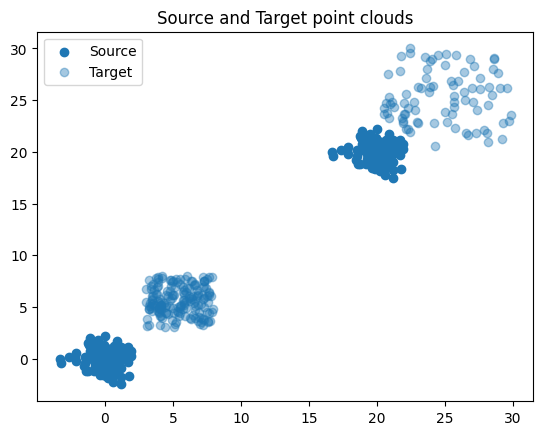

In [7]:
plt.scatter(x[:, 0], x[:, 1], label="Source", color="#1f77b4", alpha=1)
plt.scatter(y[:, 0], y[:, 1], label="Target", color="#1f77b4", alpha=0.4)
plt.legend()
plt.title("Source and Target point clouds")
plt.show()

In [8]:
geom    = pointcloud.PointCloud(x, y)
gamma0 = float(jnp.clip(geom.mean_cost_matrix / (3 * geom.epsilon), 1., 200.))
gamma0

5.904881477355957

In [9]:
# 2) instanciation du solver low-rank avec borne KL
rank = 2

base_solver = LRSinkhorn(
    rank          = 2,
    gamma         = 1e5,                 # pas MD modéré
    gamma_rescale = True,
    kwargs_dys    = {"min_entry_value":0.49},     # plancher 1/r
    lse_mode      = True
)

solver_jit  = jax.jit(base_solver)

In [10]:
def low_rank_partition(x_block: jnp.ndarray,
                       y_block: jnp.ndarray,
                       solver: Callable = solver_jit):
    """
    Renvoie labels_x, labels_y, (Q,R,g) en appelant solver(ot_prob).
    """
    # 1) Créez le geometry correctement
    geom    = pointcloud.PointCloud(x_block, y_block)
    # 2) Instanciez le problème
    ot_prob = linear_problem.LinearProblem(geom)
    # 3) Lancez le solver compilé
    out     = solver(ot_prob)

    Q, R, g = out.q, out.r, out.g

    return Q, R, g

In [11]:
# --- Exemple d’usage ---
Q, R, g = low_rank_partition(x, y)

In [12]:
labels_x = jnp.argmax(Q, axis=1)
labels_y = jnp.argmax(R, axis=1)

In [13]:
labels_x.sum(), labels_y.sum()

(Array(128, dtype=int32), Array(130, dtype=int32))

In [14]:
import jax.numpy as jnp

def simple_balanced_partition(Q: jnp.ndarray, g: jnp.ndarray):
    """
    Q: matrice (n, k) de scores pour chaque point i et cluster k
    g: vecteur (k,) de poids relatifs pour chaque cluster
    Retourne labels: (n,) avec exactement sum(labels==k) = round(g[k]*n)
    """
    n, k = Q.shape

    # 1) Capacités idéales
    caps = jnp.round(g * n).astype(int)
    # Ajuste pour que caps.sum()==n si petits décalages d'arrondi
    diff = n - caps.sum()
    if diff != 0:
        # on ajoute +1 au cluster(s) de plus grand g jusqu'à combler diff
        order = jnp.argsort(-g)
        for idx in order[:abs(diff)]:
            caps = caps.at[idx].add(jnp.sign(diff))

    # 2) Assignation simple, cluster par cluster
    labels = -jnp.ones(n, dtype=int)
    assigned = jnp.zeros(n, dtype=bool)
    # On parcourt les clusters dans l’ordre décroissant de g (pour donner priorité aux grands clusters)
    for cluster in jnp.argsort(-g):
        # indices des points non encore assignés
        rem = jnp.where(~assigned)[0]
        # on trie ces points par score Q[:,cluster] décroissant
        scores_rem = Q[rem, cluster]
        order_rem = rem[jnp.argsort(-scores_rem)]
        # on prend les premiers caps[cluster] parmi eux
        chosen = order_rem[: caps[cluster]]
        labels = labels.at[chosen].set(cluster)
        assigned = assigned.at[chosen].set(True)

    return labels

In [15]:
# 2) Labels équilibrés
partition_x = simple_balanced_partition(Q, g)
partition_y = simple_balanced_partition(R, g)

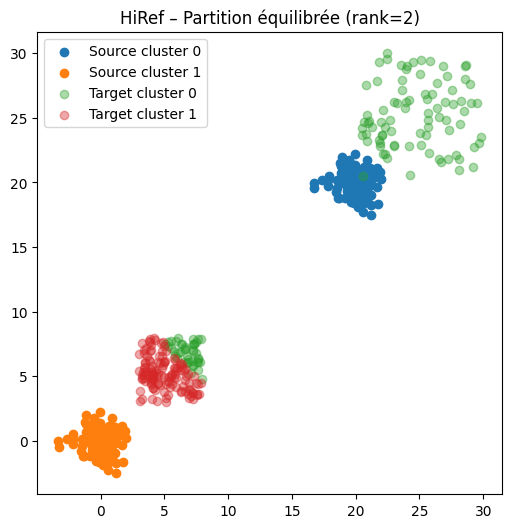

In [16]:
# 2) Labels équilibrés
partition_x = simple_balanced_partition(Q, g)
partition_y = simple_balanced_partition(R, g)

# 3) Tracé
mask_x1 = (partition_x == 0)
mask_x2 = ~mask_x1
mask_y1 = (partition_y == 0)
mask_y2 = ~mask_y1

plt.figure(figsize=(6,6))
plt.scatter(x[mask_x1,0], x[mask_x1,1],   label="Source cluster 0", alpha=1)
plt.scatter(x[mask_x2,0], x[mask_x2,1],   label="Source cluster 1", alpha=1)
plt.scatter(y[mask_y1,0], y[mask_y1,1],   label="Target cluster 0", alpha=0.4)
plt.scatter(y[mask_y2,0], y[mask_y2,1],   label="Target cluster 1", alpha=0.4)
plt.legend()
plt.title("HiRef – Partition équilibrée (rank=2)")
plt.show()

In [17]:
partition_y.sum()

Array(128, dtype=int32)

## 4. Building Hierarchical Refinement (HiRef)



In [18]:
def hiref(x: jnp.ndarray,
          y: jnp.ndarray,
          x_idx: jnp.ndarray = None,
          y_idx: jnp.ndarray = None,
          rank: int = 2,
          base_size: int = 1):
    """
    Hierarchical Refinement: returns a list of (i,j) pairs
    where i,j are indices into the original datasets.
    """
    # 0) Initialize original indices
    if x_idx is None:
        x_idx = jnp.arange(x.shape[0])
    if y_idx is None:
        y_idx = jnp.arange(y.shape[0])

    n_x, n_y = x.shape[0], y.shape[0]

    # 1) Base case: both blocks are small enough
    if n_x <= base_size and n_y <= base_size:
        return [(int(x_idx[0]), int(y_idx[0]))]

    # 2) Low-rank partition (rank=2)
    Q, R, g = low_rank_partition(x, y, solver_jit)

    lab_x = simple_balanced_partition(Q, g)
    lab_y = simple_balanced_partition(R, g)

    pairs = []
    # 3) Recurse on each cluster z
    for z in range(rank):
        mask_x    = (lab_x == z)
        mask_y    = (lab_y == z)
        x_sub     = x[mask_x]
        y_sub     = y[mask_y]

        # 3a) Skip any empty sub-block
        if x_sub.shape[0] == 0 or y_sub.shape[0] == 0:
            continue

        x_idx_sub = x_idx[mask_x]
        y_idx_sub = y_idx[mask_y]

        # 3b) Recurse
        pairs.extend(hiref(
            x_sub, y_sub,
            x_idx=x_idx_sub,
            y_idx=y_idx_sub,
            rank=rank,
            base_size=base_size
        ))

    return pairs

In [19]:
# Example usage:
pairs = hiref(x, y)

# Build the bijective transport matrix P ∈ {0,1}^{N×N}
N = x.shape[0]
P = jnp.zeros((N, N), dtype=jnp.int32)
for i, j in pairs:
    P = P.at[i, j].set(1)

# Verify each row and column sums to 1
# assert jnp.all(P.sum(axis=1) == 1)
# assert jnp.all(P.sum(axis=0) == 1)

print("Pourcentage de points transportés :", P.sum(axis=1).sum()/N*100)

Pourcentage de points transportés : 100.0


In [20]:
P.sum(axis=1).sum()
P.sum(axis=0).sum()

Array(256, dtype=int32)

In [21]:
C = jnp.sum((x[:, None, :] - y[None, :, :]) ** 2, axis=-1)
transport_cost = jnp.sum(P * C)
print("Total transport cost:", transport_cost)

Total transport cost: 24556.361


# 5. Visualizing Multiscale Alignments

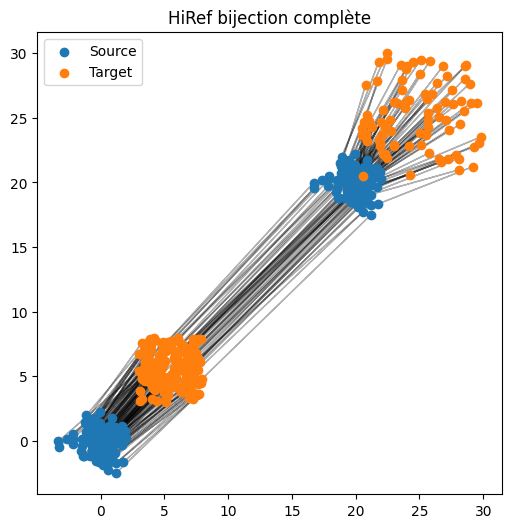

In [22]:
plt.figure(figsize=(6,6))
for i, j in pairs:
    plt.arrow(x[i,0], x[i,1],
              y[j,0] - x[i,0],
              y[j,1] - x[i,1],
              head_width=0.05, alpha=0.3, length_includes_head=True)
plt.scatter(x[:,0], x[:,1], c='C0', label='Source')
plt.scatter(y[:,0], y[:,1], c='C1', label='Target')
plt.legend(); plt.title("HiRef bijection complète"); plt.show()

> * 64 points en 1min8s

## 6. Next Step

1. Faire propre un fichier src (avec les fonctions hors du notebook)
2. Un peu mieux commenter (genre plus en mode tutorial) ce qui est déjà implémenter 
3. On utilise `rank_annealing.optimal_rank_schedule` (déjà implémenté) et on essaye de faire tourner Hiref avec ce **Rank-annealong Scedule**
4. On essaye de recoder notre propre fonction `rank_annealing.optimal_rank_schedule`

* Améliorer les explications du notebooks
    > Pourquoi gamma doit être grand? 

    > Choix initializer

    > Comparer performances (coût de transport, vistesse d'executions) avec d'autres algorithmes  
* Regarder s'il est possible d'améliorer l'efficacité de l'algorithme
* implémenter rank-annealing scheldule

# IMPLEMENTATION

#### Rank annealing (code from the repository)

#### Low Rank Parition

In [23]:
@functools.lru_cache(maxsize=10)
def get_initializer(rank):
    """
    This function is used to keep in cache the initializer initialized with the rank.
    """
    return Rank2Initializer(rank=rank)


@functools.lru_cache(maxsize=10)
def get_solver(rank):
    """
    This function is used to keep in cache the solver initialized with the rank.
    Thanks to jax.jit we can compile the function once and use it multiple times.
    """
    initializer = get_initializer(rank)
    solver = jax.jit(LRSinkhorn(
        rank=rank,
        initializer=initializer,
        gamma=1e5,
        min_iterations=20,
        threshold=1e-3
        ))
    
    return jax.jit(solver)

NameError: name 'functools' is not defined

In [ ]:
def low_rank_partition(
        x_block: jnp.ndarray,
        y_block: jnp.ndarray,
        solver: Callable         # Get the solver from the cache with get_solver
):
    """
    Renvoie labels_x, labels_y, (Q,R,g) en appelant solver(ot_prob).
    """
    # 1) Créez le geometry correctement
    geom = pointcloud.PointCloud(x_block, y_block, epsilon=1e-2)
    # 2) Instanciez le problème
    ot_prob = linear_problem.LinearProblem(geom)
    # 3) Lancez le solver compilé
    out = solver(ot_prob)

    Q, R, g = out.q, out.r, out.g

    labels_x = jnp.argmax(Q, axis=1)
    labels_y = jnp.argmax(R, axis=1)
    
    return labels_x, labels_y, (Q, R, g)

#### HiRef Algorithm

In [ ]:
import time

def hiref_solver(
        X, 
        Y,
        rank_schedule: list = None,
        ):
    """
    HiRef - version itérative utilisant ott-jax et low-rank Sinkhorn.
    
    Args:
        X (jax array): Points source (n, d).
        Y (jax array): Points cible (n, d).
        rank_schedule (list of int): Liste des rangs à utiliser à chaque profondeur.

    Returns:
        list of tuples (xi, yj): Les correspondances finales.
    """

    n = X.shape[0]
    assert X.shape[0] == Y.shape[0], "X et Y doivent avoir la même taille."

    if rank_schedule is None:
        rank_schedule = optimal_rank_schedule(n=n)
        print(f"Optimized rank-annealing schedule: { rank_schedule }")

        
    correspondances = []
    start = time.time()
    stats = [(0, start, 1, 0)]  # (t, n_s, n_c, depth)

    # Chaque élément de la pile est (x_block, y_block, martingal X, martingal Y depth)
    stack = [(X, Y, 0)]
    t = 0

    while stack:

        x_block, y_block, depth = stack.pop()

        tempo = time.time() - start
        t += 1
        ns = len(stack)
        nc = len(correspondances)
        print(f"{t} : {depth} : [Stack size: {ns}] [Correspondences size: {nc}]", end="\r")

        
        # Condition de sortie de notre boucle while. On veut que tous les éléments finissent à cette étape
        if x_block.shape[0] == 1:
            correspondances.append((x_block[0], y_block[0]))
            continue

        # Définir le rang à utiliser
        rank = rank_schedule[depth] if depth < len(rank_schedule) else 2

        ### BLOC DE RESOLUTION DES SOUS CLUSTERS
        # Géométrie
        geom = pointcloud.PointCloud(x_block, y_block)

        # Problème de transport
        ot_prob = linear_problem.LinearProblem(geom)        # pour l'instant on reste avec des lois uniformes
  
        # Initialiseur + solveur Low-Rank Sinkhorn
        solver = get_solver(rank)
        
        # Résoudre le problème de transport
        out = solver(ot_prob)

        # Récupérer Q et R
        Q = out.q
        R = out.r

        q_labels = jnp.argmax(Q, axis=1)
        r_labels = jnp.argmax(R, axis=1)

        # Pour chaque cluster
        for label in range(rank):
            idx_x = jnp.where(q_labels == label)[0]
            idx_y = jnp.where(r_labels == label)[0]

            if len(idx_x) == 0 or len(idx_y) == 0:
                continue  # Ignore clusters vides

            x_subblock = x_block[idx_x]
            y_subblock = y_block[idx_y]

            # Ajouter le sous-bloc à la pile
            stack.append((x_subblock, y_subblock, depth + 1))
        
        stats.append((t, tempo, ns, nc))

    return correspondances, stats

# Exemple

## Création de points

In [ ]:
rng = jax.random.key(4)
n, d = 256, 2
x, y = create_points(rng, n=n, d=d)

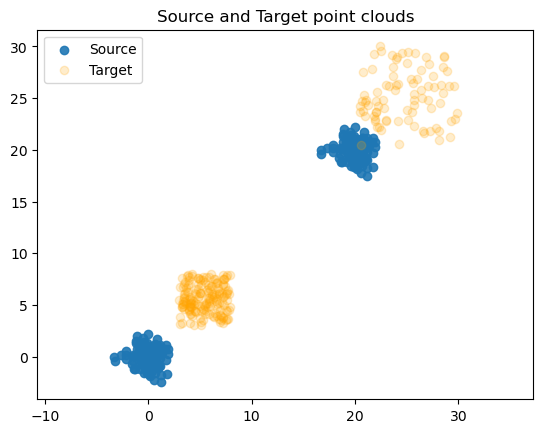

In [ ]:
plt.scatter(x[:, 0], x[:, 1], label="Source", color="#1f77b4", alpha=0.9)   # bleu opaque
plt.scatter(y[:, 0], y[:, 1], label="Target", color="orange", alpha=0.2)   # orange transparent
plt.legend()
plt.title("Source and Target point clouds")
plt.axis("equal")
plt.show()


## défintion des ranks_schedule

In [ ]:
rs1 = optimal_rank_schedule(n=n, hierarchy_depth=6, max_Q=int(n/20), max_rank=16)

Optimized rank-annealing schedule: [2, 16, 8]


In [ ]:
rs2 = optimal_rank_schedule(n=n, hierarchy_depth=10, max_Q=int(2), max_rank=2)

Optimized rank-annealing schedule: [2, 2, 2, 2, 2, 2, 2, 2]


In [ ]:
corresp1, stats1 = hiref_solver(x, y, rank_schedule=rs1)

In [ ]:
corresp2, stats2 = hiref_solver(x, y, rank_schedule=rs2)

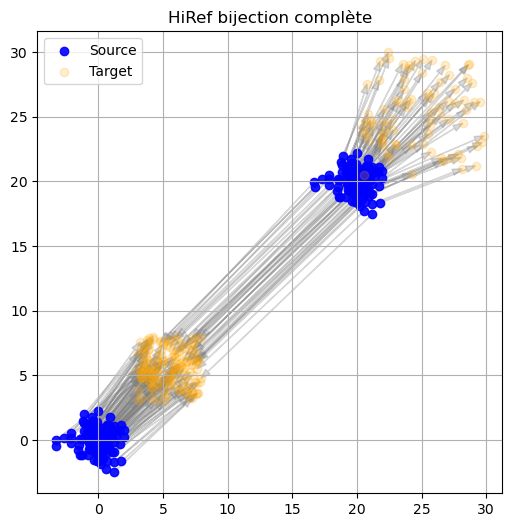

In [ ]:
plt.figure(figsize=(6, 6))

for xi, yj in corresp1:
    plt.arrow(xi[0], xi[1],
              yj[0] - xi[0],
              yj[1] - xi[1],
              head_width=0.5, alpha=0.3, length_includes_head=True, color="gray")

# Affichage des nuages
plt.scatter([xi[0] for xi, _ in corresp1], [xi[1] for xi, _ in corresp1],
            color='blue', alpha=0.9, label='Source')

plt.scatter([yj[0] for _, yj in corresp1], [yj[1] for _, yj in corresp1],
            color='orange', alpha=0.2, label='Target')

plt.legend()
plt.title("HiRef bijection complète")
plt.axis("equal")
plt.grid(True)
plt.show()
